In [74]:
import numpy as np
from scipy.io import wavfile

In [75]:
rate, data = wavfile.read('examples/self/loopback.wav')

In [76]:
data.shape[0] / rate

11.0129375

In [77]:
from matplotlib import pyplot as plt

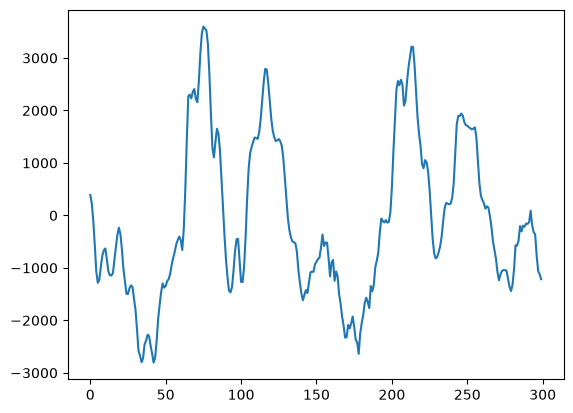

In [78]:
plt.plot(data[7500:7800])

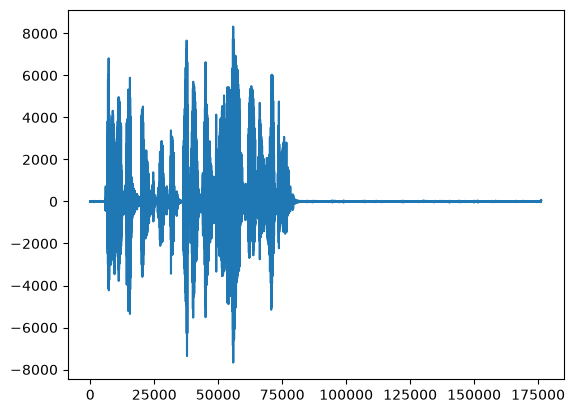

In [79]:
plt.plot(data)

In [80]:
rir = np.zeros(1000)

rir[20] = 0.8
rir[160] = 0.35
rir[420] = 0.18
rir[700] = 0.08

rir[20] = 1.0
rir[160] = 0.7
rir[420] = 0.4
rir[700] = 0.2

# Remove multi-line comment for debugging
""" 
rir = np.zeros(8000)

rir[0]    = 1.0
rir[1600] = 0.7    # 100 ms later
rir[3200] = 0.4    # 200 ms later
"""

' \nrir = np.zeros(8000)\n\nrir[0]    = 1.0\nrir[1600] = 0.7    # 100 ms later\nrir[3200] = 0.4    # 200 ms later\n'

In [81]:
mic = np.convolve(data, rir, mode="full")[:len(data)]

In [82]:
import soundfile as sf

In [83]:
from IPython.display import Audio
Audio(data, rate=rate)

In [84]:
Audio(mic, rate=rate)

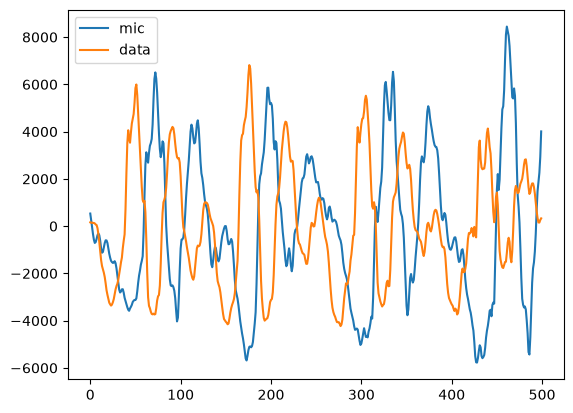

In [85]:
plt.plot(mic[7000:7500], label='mic')
plt.plot(data[7000:7500], label='data')
plt.legend()

In [86]:
mic.shape, data.shape

((176207,), (176207,))

In [87]:
import numpy as np

class LMS:
    def __init__(self, M = 10, lr=None):
        self.M = M
        self.lr = lr
        self.b = np.zeros(self.M) 
        
    def fit_transform(self, f, d):
        n_time = f.shape[0]
        loss = []
        y = np.copy(f)
        for n in range(self.M - 1, n_time):
            f_window = f[n - self.M + 1 : n+1][::-1]
            y_n = np.dot(f_window, self.b)
            y[n] = y_n
            e = d[n] - y_n
            loss.append(e**2)
            self.b = self.b + self.lr * e * f_window

        return loss, y
                
    def find_lr(self, f, safety=0.1):
        f = np.asarray(f, dtype=np.float64)

        X = np.lib.stride_tricks.sliding_window_view(f, self.M)
        X = X[:, ::-1]

        R = (X.T @ X) / len(X)
        lambda_max = np.linalg.eigvalsh(R)[-1]
        lr_max = 2.0 / lambda_max
        lr = safety * lr_max

        return lr, lr_max

In [172]:
lms = LMS(320)
lms.lr, _ = lms.find_lr(mic[:75000])
lms.lr = lms.lr / 20
loss_list = []
y_list = []
for _ in range(20):
    loss, y = lms.fit_transform(mic[:75000], data[:75000])
    y_list.append(y)
    mean_loss = sum(loss) / len(loss)
    loss_list.append(mean_loss)

310082.67583722336 295042.8703869478


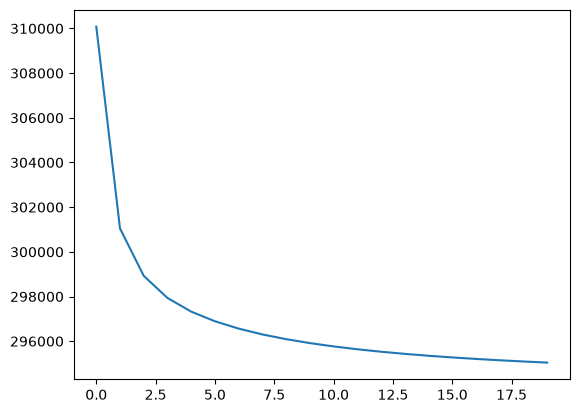

In [173]:
print(max(loss_list), min(loss_list))
plt.plot(loss_list)


In [174]:
np.sqrt(min(loss_list))

np.float64(543.1784885163879)

In [175]:
Audio(y_list[-1], rate=rate)

In [176]:
Audio(mic[:75000], rate=rate)

In [177]:
Audio(data[:75000], rate=rate)

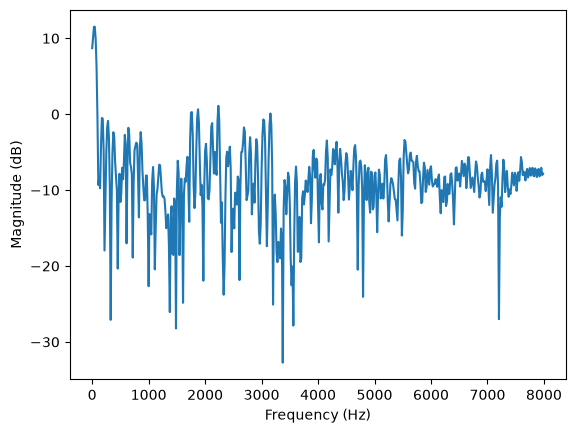

In [178]:
N = 1024

B = np.fft.fft(lms.b, N)
magnitude_db = 20 * np.log10(np.abs(B) + 1e-12)

freq = np.fft.fftfreq(N, d=1/16000)

plt.plot(freq[:N//2], magnitude_db[:N//2])
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.show()

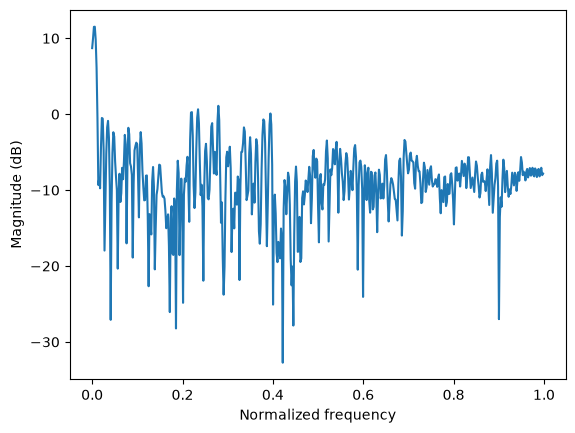

In [179]:
from scipy.signal import freqz
import matplotlib.pyplot as plt
import numpy as np

w, h = freqz(lms.b)

plt.plot(
    w / np.pi,
    20 * np.log10(np.abs(h) + 1e-12)
)

plt.xlabel("Normalized frequency")
plt.ylabel("Magnitude (dB)")
plt.show()

Text(0, 0.5, 'Magnitude (dB)')

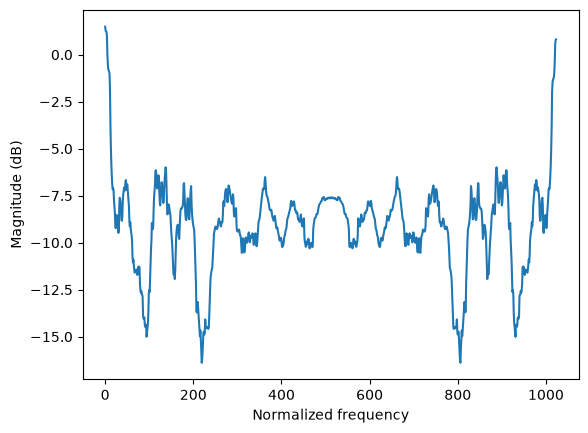

In [180]:
window = 20
smooth = np.convolve(
    magnitude_db,
    np.ones(window) / window,
    mode="same"
)

plt.plot(smooth)
plt.xlabel("Normalized frequency")
plt.ylabel("Magnitude (dB)")

Text(0, 0.5, 'Magnitude (dB)')

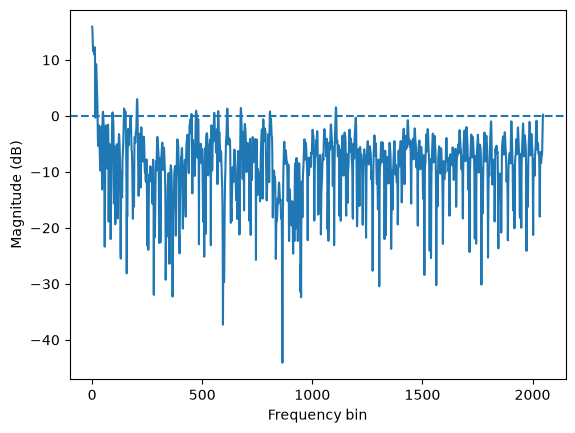

In [181]:
N = 4096

H = np.fft.rfft(rir, N)
B = np.fft.rfft(lms.b, N)

combined = H * B

combined_db = 20 * np.log10(np.abs(combined) + 1e-12)

plt.plot(combined_db)
plt.axhline(0, linestyle="--")
plt.xlabel("Frequency bin")
plt.ylabel("Magnitude (dB)")

Text(0, 0.5, 'Relative magnitude (dB)')

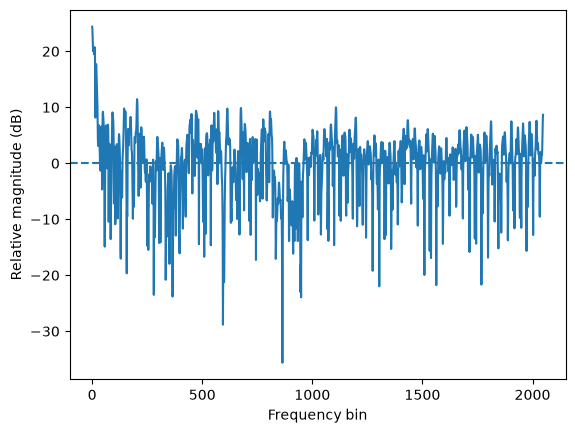

In [182]:
combined_db_relative = combined_db - np.mean(combined_db)

plt.plot(combined_db_relative)
plt.axhline(0, linestyle="--")
plt.xlabel("Frequency bin")
plt.ylabel("Relative magnitude (dB)")